In [13]:
import os 
from pathlib import Path
import sys
from typing import Dict, List, Tuple, Optional

import numpy as np
import xarray as xr

import matplotlib.pyplot as plt

CWD = Path.cwd().resolve()
PROJECT_ROOT = next(
    (candidate for candidate in [CWD, *CWD.parents] if (candidate / "scripts").exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate pcmdi_package/scripts.")
SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

from pcmdi_enso_reader import ENSODiagReader
from enso_feature_sources import (
    EnsembleSource, load_ensemble_variable, load_pcmdi_variable,
)
from metrics_group_merger import PCMDIRun


In [14]:
class ENSODiagPlotter:
    """
    Plot ENSO amplitude diagnostics (e.g., SSTA std vs longitude)
    using a data_dict that contains:
      - 'reference': obs DataArray
      - 'hist', 'future', ... : model DataArrays (member/sample, longitude)
    """

    def __init__(
        self,
        data_dict: dict,
        fig_dir: str,
        plot_dict: dict,
        group_order=("hist", "future"),
        obs_key: str = "reference",
    ):
        """
        Parameters
        ----------
        data_dict : dict
            {
              'reference': obs DataArray,
              'hist':      model DataArray,
              'future':    model DataArray,
              ...
            }
        fig_dir : str
            Directory where figures are saved.
        plot_dict : dict
            Styling and labels for each key in data_dict, e.g.
              {
                "reference": {"label": "...", "color": "black",   "alpha": 0.55},
                "hist":      {"label": "...", "color": "steelblue","alpha": 0.55},
                "future":    {"label": "...", "color": "tomato",  "alpha": 0.55},
              }
        group_order : sequence
            Order of model groups to plot and to stack into the 'period' dim.
        obs_key : str
            Key in data_dict / plot_dict for observations.
        """
        self.data_dict   = data_dict
        self.fig_dir     = fig_dir
        self.plot_dict   = plot_dict
        self.group_order = tuple(group_order)
        self.obs_key     = obs_key

        # Build ds_amp (metric with dims: period, member, longitude) and obs_da
        self.ds_amp, self.obs_da = self._build_amp_and_obs()

    def _build_amp_and_obs(self) -> tuple[xr.Dataset, xr.DataArray]:
        """Build ds_amp['metric'] and obs_da from data_dict."""
        # ---- observation ----
        if self.obs_key not in self.data_dict:
            raise ValueError(f"data_dict must contain obs_key='{self.obs_key}'")

        obs_da = self.data_dict[self.obs_key]
        if "longitude" in obs_da.dims:
            extra = [d for d in obs_da.dims if d != "longitude"]
            if extra:
                obs_da = obs_da.mean(dim=extra)

        # ---- model fields → metric(period, member, longitude) ----
        amp_list = []
        for group in self.group_order:
            if group not in self.data_dict:
                raise ValueError(
                    f"Expected group '{group}' in data_dict, found keys: {list(self.data_dict.keys())}"
                )
            da_g = self.data_dict[group]

            # ensure there is a 'member' dim
            if "member" not in da_g.dims:
                if "sample" in da_g.dims:
                    da_g = da_g.rename({"sample": "member"})
                elif len(da_g.dims) == 2 and "longitude" in da_g.dims:
                    # heuristic: the other dim is member-like
                    other = [d for d in da_g.dims if d != "longitude"][0]
                    da_g = da_g.rename({other: "member"})

            # average any extra dims beyond (member, longitude)
            extra_dims = [d for d in da_g.dims if d not in ("member", "longitude")]
            if extra_dims:
                da_g = da_g.mean(dim=extra_dims)

            # add a period coord with value = group name
            da_g = da_g.expand_dims(period=[group])
            amp_list.append(da_g)

        metric = xr.concat(amp_list, dim="period")  # (period, member, longitude)
        ds_amp = metric.to_dataset(name="metric")
        return ds_amp, obs_da

    def _prep_amp(self) -> xr.DataArray:
        """
        Return amplitude DataArray from ds_amp['metric'].
        Dims: (period, member, longitude)
        """
        da = self.ds_amp["metric"]
        extra_dims = [d for d in da.dims if d not in ("period", "member", "longitude")]
        if extra_dims:
            da = da.mean(dim=extra_dims)
        return da
        
    @staticmethod
    def _format_lon(lon):
        """
        Convert longitude in degrees to string label.
        Assumes lon in [0, 360]; adjust if needed.
        """
        lon = float(lon)
        if lon == 0 or lon == 360:
            return "0°"
        if lon == 180:
            return "180°"
        if lon < 180:
            return f"{int(lon)}°E"
        else:
            return f"{int(360 - lon)}°W"
            
    def plot_var_lon(
        self,
        filename: str = "enso_amplitude_hist_future_ens.pdf",
        ymin: Optional[float] = None,
        ymax: Optional[float] = None,
        show_spread: bool = True,
        title: str = "ENSO amplitude (SSTA standard deviation)",
        xlabel: str = "longitude",
        ylabel: str = r"SSTA std ($^\circ$C)",
        xint: int = 30, 
        figsize: tuple = (5, 4),
        fontz: int = 12,
        fig_dpi: int = 150,
        fig_format: str = "png",
    ):
        da  = self._prep_amp()               # (period, member, longitude)
        lon = da["longitude"].values
    
        fig = plt.figure(figsize=figsize)
        # Force fixed subplot geometry (critical for combined layout)
        gs = fig.add_gridspec(
            1, 1,
            left=0.18,    # margin left
            right=0.97,   # margin right
            bottom=0.16,  # margin bottom
            top=0.90      # margin top
        )
        
        ax = fig.add_subplot(gs[0, 0])

        # --- font sizes ---
        ax.set_xlabel(xlabel, fontsize=fontz * 1.0)
        ax.set_ylabel(ylabel, fontsize=fontz * 1.0)
        ax.set_title(title,  fontsize=fontz * 1.1, loc="left")
        ax.tick_params(
            axis="both", 
            length=8,         # tick length (points)
            width=0.8,        # tick line width
            direction="out",  # or "in", "inout"
            labelsize=fontz * 0.95
        )

        
        # --- observations (from data_dict[obs_key]) ---
        if self.obs_da is not None:
            obs = self.obs_da
            if "longitude" in obs.dims:
                obs_vals = obs.sel(longitude=lon, method="nearest")
            else:
                obs_vals = obs

            obs_style = self.plot_dict.get(self.obs_key, {})
            obs_label = obs_style.get("label", "Reference")
            obs_color = obs_style.get("color", "black")

            ax.plot(
                lon,
                obs_vals,
                linewidth=2,
                color=obs_color,
                label=obs_label,
            )
    
        # --- ensemble curves for each period/group ---
        for pval in da["period"].values:
            key = str(pval)   # e.g. "hist", "future"
            style = self.plot_dict.get(key, {})
            label = style.get("label", key)
            color = style.get("color", None)
            alpha_fill = style.get("alpha", 0.2)

            da_p   = da.sel(period=pval)   # (member, longitude)
            mean_p = da_p.mean("member")
            std_p  = da_p.std("member")
    
            line = ax.plot(
                lon, mean_p,
                linewidth=2,
                label=label,
                color=color,
            )[0]
            if color is None:
                color = line.get_color()
    
            if show_spread:
                ax.fill_between(
                    lon, mean_p - std_p, mean_p + std_p,
                    color=color, alpha=alpha_fill, linewidth=0,
                )
    
        # --- longitude ticks / labels ---
        lon_min = float(lon.min())
        lon_max = float(lon.max())
        lon_min_rounded = np.floor(lon_min / xint) * xint
        lon_max_rounded = np.ceil(lon_max / xint) * xint
        xticks = np.arange(lon_min_rounded, lon_max_rounded + 1e-6, xint)
    
        ax.set_xticks(xticks)
        ax.set_xticklabels(
            [self._format_lon(x) for x in xticks],
            fontsize=fontz * 0.95,
        )
    
        if ymin is not None or ymax is not None:
            ax.set_ylim(ymin, ymax)
            
        ax.grid(True, linestyle="--", alpha=0.5)
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(
            handles, labels,
            loc="upper center",
            bbox_to_anchor=(0.5, -0.18),
            ncol=max(1, (len(handles) + 1) // 2),
            frameon=True,
            fontsize=fontz * 0.9,
        )
    
        out_path = os.path.join(self.fig_dir, filename)
        
        fig.subplots_adjust(
            left=0.22, right=0.97, bottom=0.32, top=0.90
        )
        
        fig.savefig(
            out_path, 
            dpi=fig_dpi, 
            format=fig_format, 
            bbox_inches="tight", 
            pad_inches=0.05
        )
        
        print(f"Saved ENSO amplitude diagnostic figure to {out_path}")
        return fig, ax


processing period: hist
enso_amplitude/historical: case=v20260212, shape=(25, 120), dims=('member', 'longitude')
processing period: future
enso_amplitude/future: case=v20260212, shape=(25, 120), dims=('member', 'longitude')
Saved ENSO amplitude diagnostic figure to /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/paper_plot/enso_enso_amplitude_historical_vs_future.pdf
processing period: hist
enso_sst_skewness/historical: case=v20260212, shape=(25, 120), dims=('member', 'longitude')
processing period: future
enso_sst_skewness/future: case=v20260212, shape=(25, 120), dims=('member', 'longitude')
Saved ENSO amplitude diagnostic figure to /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/paper_plot/enso_enso_sst_skewness_historical_vs_future.pdf


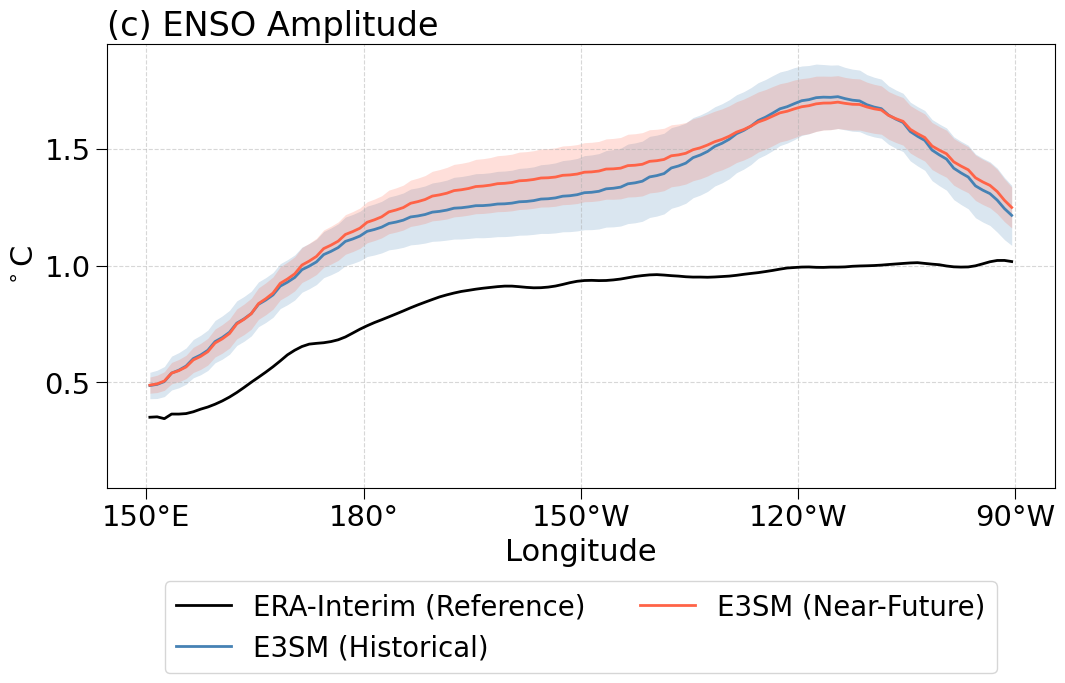

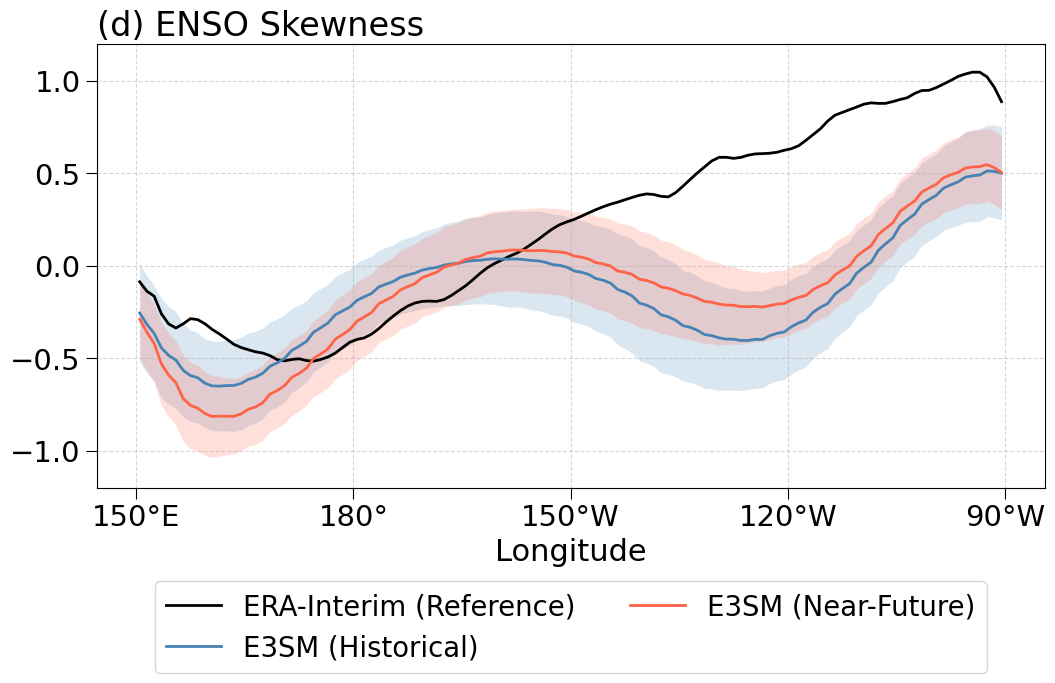

In [15]:
# =====================================================================
# SETUP / CONFIGURATION
# =====================================================================

# --- Paths ----------------------------------------------------------------
DATA_DIR = Path("/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le")
FIG_DIR = DATA_DIR / "paper_plot"

# --- Run / diagnostic settings ----------------------------------------------
RUN_PLOTS = True
READER_VERBOSE = False
DIAGNOSTIC_PRINT = True
POOL_MEMBERS_TO_SAMPLES = False

# --- Reference settings ------------------------------------------------------
REFERENCE_SET = "ERA-Interim"
DEFAULT_CASE_ID = "v20260212"
REFERENCE_SETS = {"ERA-Interim": {"hist": "ERA-Interim", "future": "FAKE-FUTURE1"}}

# --- Comparison groups (ensembles / runs to compare) --------------------------
COMPARISON_GROUPS = [
    {
        "key": "historical", "label": "E3SM (Historical)", "color": "steelblue",
        "source": EnsembleSource(DATA_DIR, "v3.LR.historical", "hist", (1985, 2014), 25),
    },
    {
        "key": "future", "label": "E3SM (Near-Future)", "color": "tomato",
        "source": EnsembleSource(DATA_DIR, "v3.LR.historical", "future", (2015, 2049), 25),
    },
]

# --- Figure numbering -----------------------------------------------------
FIG_INDEX_START = 2

# --- Lon plot styling settings -----------------------------------------------
REFERENCE_COLOR = "black"
LON_LINE_ALPHA = 0.2
LON_FIGSIZE = (12, 6)
LON_FONT_SIZE = 22
LON_SHOW_SPREAD = True
FIG_DPI = 300
FIG_FORMAT = "pdf"

# --- Per-metric plot configs ------------------------------------------------
TARGET_METRICS = {
    "enso_amplitude": {
        "group": "ENSO_perf",
        "suffix": "EnsoAmpl",
        "variables": {"sstStd_lon": "SSTA standard deviation"},
        "label": "ENSO Amplitude",
        "unit": r"$^\circ$C",
        "ylim": (0.05, 1.95),
        "rtol": 1e-2,
    },
    "enso_sst_skewness": {
        "group": "ENSO_perf",
        "suffix": "EnsoSstSkew",
        "variables": {"sstSke_lon": "SSTA skewness"},
        "label": "ENSO Skewness",
        "unit": "",
        "ylim": (-1.2, 1.2),
        "rtol": 1e-2,
    },
}


# =====================================================================
# FUNCTIONS
# =====================================================================

def run_lon_comparison(groups, output_suffix=""):
    keys = [x["key"] for x in groups]
    if not keys or len(keys) != len(set(keys)):
        raise ValueError(f"Invalid comparison keys: {keys}")

    styles = {
        "reference": {"label": f"{REFERENCE_SET} (Reference)", "color": REFERENCE_COLOR, "alpha": LON_LINE_ALPHA},
        **{x["key"]: {"label": x["label"], "color": x["color"], "alpha": LON_LINE_ALPHA} for x in groups},
    }

    outputs = []
    for mi, (metric, cfg) in enumerate(TARGET_METRICS.items()):
        for vi, (var, var_label) in enumerate(cfg["variables"].items()):
            data = {}
            refs = []
            for item in groups:
                src = item["source"]
                if isinstance(src, EnsembleSource):
                    model, ref, cid = load_ensemble_variable(
                        src, metric, cfg, var,
                        REFERENCE_SETS[REFERENCE_SET][src.group],
                        DEFAULT_CASE_ID,
                        verbose=READER_VERBOSE,
                        pool_members=POOL_MEMBERS_TO_SAMPLES,
                    )
                elif isinstance(src, PCMDIRun):
                    model, ref, cid = load_pcmdi_variable(src, cfg, var, item.get("obs_tag"))
                else:
                    raise TypeError("source must be EnsembleSource or PCMDIRun")

                data[item["key"]] = model
                refs.append(ref)
                if DIAGNOSTIC_PRINT:
                    print(f"{metric}/{item['key']}: case={cid}, shape={model.shape}, dims={model.dims}")

            refs = xr.align(*refs, join="exact")
            if any(not np.allclose(refs[0], r, rtol=cfg["rtol"], atol=0, equal_nan=True) for r in refs[1:]):
                raise ValueError(f"{metric}: inconsistent references")

            data["reference"] = refs[0]
            tag = "_vs_".join(keys)
            plotter = ENSODiagPlotter(data, FIG_DIR, styles, keys, obs_key="reference")
            outputs.append(
                plotter.plot_var_lon(
                    filename=f"enso_{metric}_{tag}{output_suffix}.pdf",
                    ymin=cfg["ylim"][0],
                    ymax=cfg["ylim"][1],
                    title=f"({chr(mi + vi + FIG_INDEX_START + 97)}) {cfg['label']}",
                    xlabel="Longitude",
                    ylabel=cfg["unit"],
                    fontz=LON_FONT_SIZE,
                    figsize=LON_FIGSIZE,
                    show_spread=LON_SHOW_SPREAD,
                    fig_dpi=FIG_DPI,
                    fig_format=FIG_FORMAT,
                )
            )
    return outputs


# =====================================================================
# EXECUTION
# =====================================================================

if RUN_PLOTS:
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    run_lon_comparison(COMPARISON_GROUPS)
else:
    print("Set RUN_PLOTS = True after reviewing COMPARISON_GROUPS.")

enso_amplitude/v3lr_0051: case=v20260212, shape=(1, 120), dims=('member', 'longitude')
enso_amplitude/v3lr_0091: case=v20260212, shape=(1, 120), dims=('member', 'longitude')
enso_amplitude/v3lr_0101: case=v20260212, shape=(1, 120), dims=('member', 'longitude')
enso_amplitude/v3lr_0111: case=v20260212, shape=(1, 120), dims=('member', 'longitude')


/tmp/ipykernel_1191597/1287284923.py:89: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'member' ('member',) The recommendation is to set join explicitly for this case.
  metric = xr.concat(amp_list, dim="period")  # (period, member, longitude)


Saved ENSO amplitude diagnostic figure to /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/paper_plot/enso_enso_amplitude_v3lr_0051_vs_v3lr_0091_vs_v3lr_0101_vs_v3lr_0111_standalone.pdf
enso_sst_skewness/v3lr_0051: case=v20260212, shape=(1, 120), dims=('member', 'longitude')
enso_sst_skewness/v3lr_0091: case=v20260212, shape=(1, 120), dims=('member', 'longitude')
enso_sst_skewness/v3lr_0101: case=v20260212, shape=(1, 120), dims=('member', 'longitude')
enso_sst_skewness/v3lr_0111: case=v20260212, shape=(1, 120), dims=('member', 'longitude')
Saved ENSO amplitude diagnostic figure to /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/paper_plot/enso_enso_sst_skewness_v3lr_0051_vs_v3lr_0091_vs_v3lr_0101_vs_v3lr_0111_standalone.pdf


/tmp/ipykernel_1191597/1287284923.py:89: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'member' ('member',) The recommendation is to set join explicitly for this case.
  metric = xr.concat(amp_list, dim="period")  # (period, member, longitude)


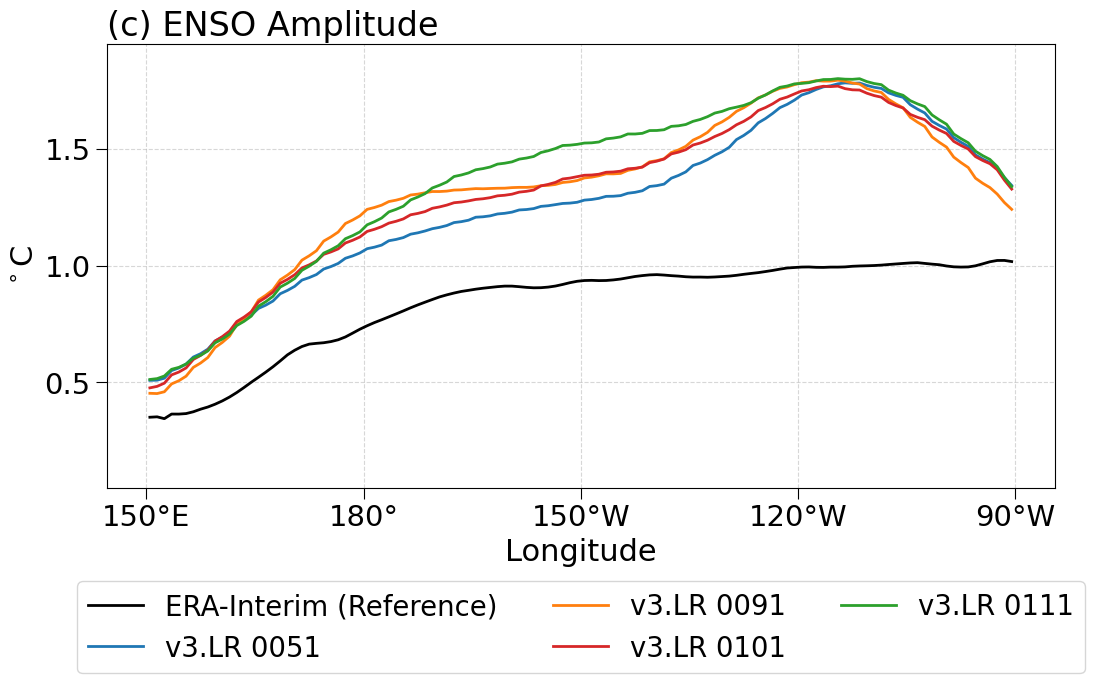

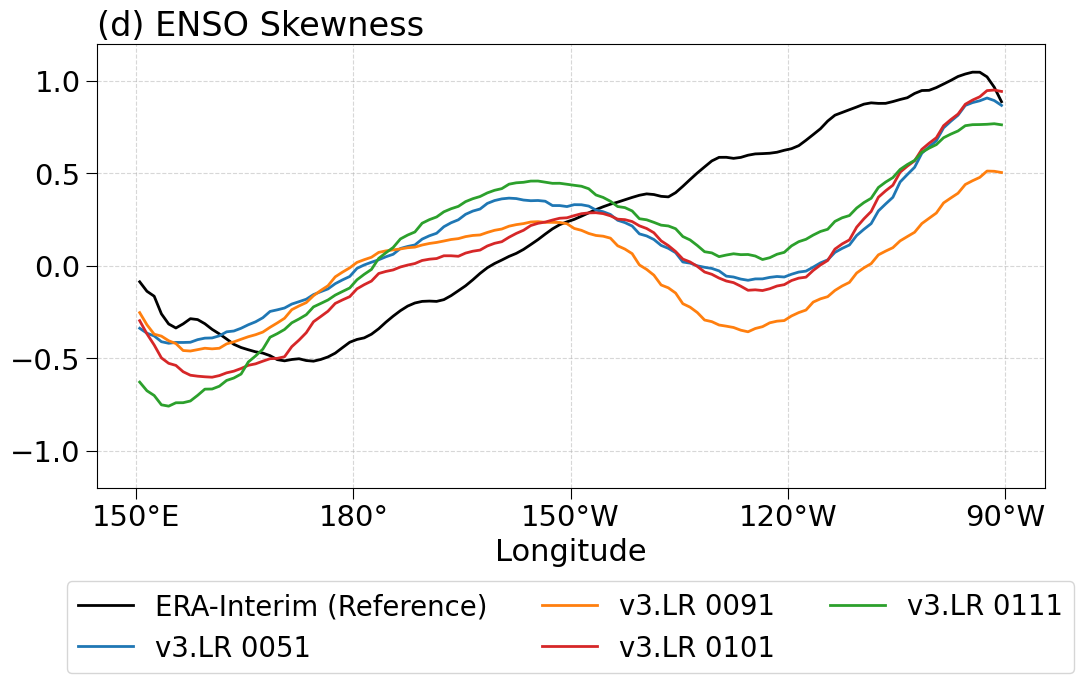

In [ ]:
# =====================================================================
# STANDALONE PCMDI-RUN TEST (one member per plotted group) — lon plots
# =====================================================================
# Overrides COMPARISON_GROUPS above to compare four individual v3.LR
# historical members directly, rather than pooled ensembles.

# --- Setup / configuration --------------------------------------------
RUN_STANDALONE_PLOTS = True
STANDALONE_INPUT_DIR = DATA_DIR / "hist"
STANDALONE_OUTPUT_SUFFIX = "_standalone"

#OUT_FIG_DIR = Path("/global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi/analysis_output/enso_feature_metrics")
#INPUT_DATA_DIR = Path("/global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi")
# Example: four standalone PCMDI runs (one member per plotted group).
# COMPARISON_GROUPS = [
#     {"key": "v3_lr", 
#      "label": "v3.LR.CPL", 
#      "color": "tab:blue",
#      "source": PCMDIRun(case="20231209.v3.LR.piControl-spinup.chrysalis",
#                         model_name="EAMXX-ne256_coupled-test", 
#                         metrics_case_id="v20260531",
#                         output_name="v3.LR.CPL", 
#                         www=INPUT_DATA_DIR)
#     },
#     {"key": "v3_hr", 
#      "label": "v3.HR.CPL", 
#      "color": "tab:orange",
#      "source": PCMDIRun(case="20250906.wcycl1850.ne120pg2_r025_RRSwISC6to18E3r5.test6.1.chrysalis",
#                         model_name="v3-HR_test6-1", 
#                         metrics_case_id="v20260601",
#                         output_name="v3.HR.CPL", 
#                         www=INPUT_DATA_DIR)
#     },
#     {"key": "v4p", 
#      "label": "v4P.CPL",
#      "color": "tab:red",
#      "source": PCMDIRun(case="20260204.ne256.WCYCLXX1850.SOI",
#                         model_name="EAMXX-ne256_coupled-test", 
#                         metrics_case_id="v20260601",
#                         output_name="v4P.CPL", 
#                         www=INPUT_DATA_DIR)
#     },
#     {"key": "v4p_amip", 
#      "label": "v4P.AMIP",
#      "color": "tab:green",
#      "source": PCMDIRun(case="ne256pg2_ne256pg2.F20TR-SCREAMv1.July-1.spanc800.2xauto.acc150.n0032.test2.1",
#                         model_name="EAMXX_test2_1", 
#                         metrics_case_id="v20260531",
#                         output_name="v4P.AMIP", 
#                         www=INPUT_DATA_DIR)
#     },
# ]

STANDALONE_MEMBERS = [
    {"key": "v3lr_0051", "label": "v3.LR 0051", "color": "tab:blue", "case": "v3.LR.historical_0051", "model_name": "v3-LR_0051"},
    {"key": "v3lr_0091", "label": "v3.LR 0091", "color": "tab:orange", "case": "v3.LR.historical_0091", "model_name": "v3-LR_0091"},
    {"key": "v3lr_0101", "label": "v3.LR 0101", "color": "tab:red", "case": "v3.LR.historical_0101", "model_name": "v3-LR_0101"},
    {"key": "v3lr_0111", "label": "v3.LR 0111", "color": "tab:green", "case": "v3.LR.historical_0111", "model_name": "v3-LR_0111"},
]
STANDALONE_METRICS_CASE_ID = "v20260212"

# --- Build comparison groups from member definitions ---------------------
COMPARISON_GROUPS = [
    {
        "key": member["key"],
        "label": member["label"],
        "color": member["color"],
        "source": PCMDIRun(
            case=member["case"],
            model_name=member["model_name"],
            metrics_case_id=STANDALONE_METRICS_CASE_ID,
            output_name=member["label"],
            www=STANDALONE_INPUT_DIR,
        ),
    }
    for member in STANDALONE_MEMBERS
]

# --- Execution -----------------------------------------------------------
if RUN_STANDALONE_PLOTS:
    run_lon_comparison(COMPARISON_GROUPS, output_suffix=STANDALONE_OUTPUT_SUFFIX)
else:
    print("Set RUN_STANDALONE_PLOTS = True after reviewing the four runs above.")